# 02 - Anatomía de un Partido: Argentina vs Francia (Final Mundial 2022)

Análisis detallado del partido evento por evento. Calculamos métricas de posesión, 
pases, presión y actividad por jugador para entender cómo se jugó la final.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

# Cargar el partido final
matches = sb.matches(competition_id=43, season_id=106)
final_id = matches[
    (matches['home_team'].isin(['Argentina', 'France'])) & 
    (matches['away_team'].isin(['Argentina', 'France']))
]['match_id'].iloc[0]

events = sb.events(match_id=final_id)
print(f"Eventos cargados: {len(events)}")

Eventos cargados: 4407


## 1. Análisis de pases por equipo

Calculamos pases totales, completados y precisión por equipo.

In [2]:
# Filtrar solo pases
pases = events[events['type'] == 'Pass'].copy()

# En StatsBomb, si pass_outcome es NaN significa que el pase fue completado
# Si tiene valor (Incomplete, Out, Pass Offside, etc) significa que falló
pases['completado'] = pases['pass_outcome'].isna()

# Resumen por equipo
resumen_pases = pases.groupby('team').agg(
    total_pases=('completado', 'count'),
    pases_completados=('completado', 'sum')
).reset_index()

resumen_pases['precision_pct'] = (
    resumen_pases['pases_completados'] / resumen_pases['total_pases'] * 100
).round(1)

print(resumen_pases)

        team  total_pases  pases_completados  precision_pct
0  Argentina          693                560           80.8
1     France          570                434           76.1


## 2. Jugadores más activos

¿Quiénes tocaron más el balón? Esto nos da una primera lectura de quién condujo el juego.

In [3]:
# Top 10 jugadores con más eventos
top_jugadores = events.groupby(['player', 'team']).size().reset_index(name='eventos')
top_jugadores = top_jugadores.sort_values('eventos', ascending=False).head(15)
print(top_jugadores.to_string(index=False))

                         player      team  eventos
                 Enzo Fernandez Argentina      328
 Lionel Andrés Messi Cuccittini Argentina      242
         Rodrigo Javier De Paul Argentina      242
        Nicolás Hernán Otamendi Argentina      215
                   Jules Koundé    France      211
      Aurélien Djani Tchouaméni    France      205
        Cristian Gabriel Romero Argentina      203
       Dayotchanculle Upamecano    France      198
            Alexis Mac Allister Argentina      196
                 Raphaël Varane    France      182
                  Adrien Rabiot    France      176
   Nicolás Alejandro Tagliafico Argentina      165
                 Julián Álvarez Argentina      150
           Kylian Mbappé Lottin    France      149
Theo Bernard François Hernández    France      145


## 3. Mapa de tiros del partido

Visualización de todos los intentos a portería con su xG asociado.

In [4]:
# Filtrar todos los tiros
tiros = events[events['type'] == 'Shot'].copy()

# Extraer coordenadas X y Y de la columna location (que es una lista [x, y])
tiros['x'] = tiros['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
tiros['y'] = tiros['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)

# Identificar goles
tiros['es_gol'] = tiros['shot_outcome'] == 'Goal'

# Resumen
print(f"Total de tiros: {len(tiros)}")
print(f"Goles: {tiros['es_gol'].sum()}")
print(f"\nxG total por equipo:")
print(tiros.groupby('team')['shot_statsbomb_xg'].sum().round(2))

Total de tiros: 38
Goles: 12

xG total por equipo:
team
Argentina    5.89
France       5.41
Name: shot_statsbomb_xg, dtype: float64


### Visualización: Shot Map con mplsoccer

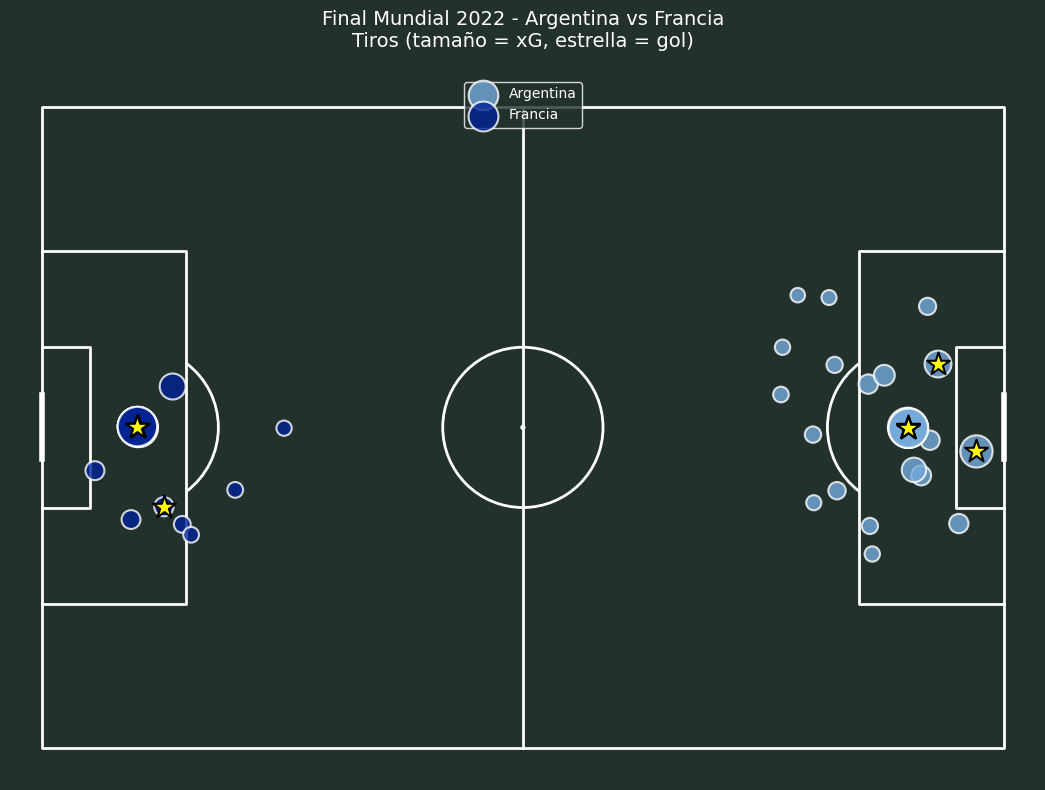

In [5]:
from mplsoccer import Pitch

# Crear el campo
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#22312b')

# Separar tiros por equipo
arg_tiros = tiros[tiros['team'] == 'Argentina']
fra_tiros = tiros[tiros['team'] == 'France']

# Para Argentina, invertir coordenadas (atacan de derecha a izquierda en la viz)
# Pintar tiros de Argentina
pitch.scatter(
    arg_tiros['x'], arg_tiros['y'],
    s=arg_tiros['shot_statsbomb_xg'] * 900 + 100,  # tamaño proporcional al xG
    c='#75AADB',  # celeste Argentina
    edgecolors='white',
    linewidth=1.5,
    alpha=0.8,
    ax=ax,
    label='Argentina'
)

# Pintar tiros de Francia (invertir X para que ataquen al lado opuesto)
pitch.scatter(
    120 - fra_tiros['x'], 80 - fra_tiros['y'],
    s=fra_tiros['shot_statsbomb_xg'] * 900 + 100,
    c='#002395',  # azul Francia
    edgecolors='white',
    linewidth=1.5,
    alpha=0.8,
    ax=ax,
    label='Francia'
)

# Marcar los goles con un símbolo distintivo
for _, gol in tiros[tiros['es_gol']].iterrows():
    x, y = gol['x'], gol['y']
    if gol['team'] == 'France':
        x, y = 120 - x, 80 - y
    pitch.scatter(x, y, s=300, marker='*', c='yellow', 
                  edgecolors='black', linewidth=1.5, ax=ax, zorder=5)

plt.title('Final Mundial 2022 - Argentina vs Francia\nTiros (tamaño = xG, estrella = gol)', 
          color='white', fontsize=14, pad=20)
plt.legend(loc='upper center', facecolor='#22312b', edgecolor='white', labelcolor='white')

plt.savefig('../outputs/figures/shot_map_final_2022.png', 
            dpi=150, bbox_inches='tight', facecolor='#22312b')
plt.show()

## 4. Posesión por intervalos de 15 minutos

¿Cómo evolucionó el control del partido?

In [6]:
# Crear intervalos de 15 minutos
events['intervalo'] = pd.cut(
    events['minute'],
    bins=[0, 15, 30, 45, 60, 75, 90, 120],
    labels=['0-15', '15-30', '30-45', '45-60', '60-75', '75-90', '90+']
)

# Calcular posesión por intervalo y equipo
posesion = events.groupby(['intervalo', 'team']).size().unstack(fill_value=0)
posesion_pct = posesion.div(posesion.sum(axis=1), axis=0) * 100
print(posesion_pct.round(1))

team       Argentina  France
intervalo                   
0-15            57.0    43.0
15-30           56.4    43.6
30-45           66.7    33.3
45-60           42.1    57.9
60-75           37.4    62.6
75-90           51.4    48.6
90+             58.4    41.6


## 5. Conclusiones del análisis

1. Argentina dominó la mayor parte del encuentro, especialmente en los primeros 60 minutos. Francia estuvo "fuera" del partido hasta el último cuarto del tiempo reglamentario, donde su actividad creció exponencialmente tras los cambios tácticos.

2. La actividad de Argentina no fue solo por los laterales, sino que tuvo una alta densidad en el último tercio.

3. Los Expected Goals (xG) revelan que las probabilidades de gol fueron muy distintas en su origen. Mientras que los goles de Argentina vinieron de jugadas de construcción y penales en momentos de dominio claro, los de Francia fueron explosiones de eficiencia en periodos cortos de alta intensidad.